# Reconstruction de l'environnement à l'aide d'un CNN à partir des signaux reçus

## Données

C'est un fichier .mat avec un champ "data" qui contient une matrice de 41 * 2001 signaux et un champ "map" qui contient l'état réel de la carte

Le code fait un apprentissage basique à développer plus


# 1) Imports

In [4]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import random
import copy
import os

# 2) Charger les données

In [9]:
if not os.path.exists('data'):
    print("⚠️ Erreur : Le dossier 'data' est manquant. Consultez le README pour le télécharger.")
else:
    data = loadmat('./data/recalcul_bon.mat')["results"]
    data = data.squeeze()

# Liste python pour faciliter l'itération
list_experiments=[]

for exp in data:
    list_experiments.append(exp)

ValueError: Unknown mat file type, version 242, 208

In [24]:
data.shape

(131,)

In [25]:
class SonarDataset(Dataset):
    def __init__(self, data_array):
        # On initialise des listes vides pour stocker nos tenseurs
        self.inputs = []
        self.targets = []

        # On boucle sur les 131 échantillons
        for i in range(data_array.shape[0]):
            echantillon = data_array[i]

            # Scipy rajoute souvent des dimensions inutiles lors de l'import MATLAB
            # Le [0,0] ou [0] permet d'accéder à la vraie matrice
            signal = echantillon['data'][0,0] # Matrice 41 x 2001
            carte = echantillon['map'][0,0]   # Matrice de la carte 2D

            # PyTorch pour les CNN attend des données sous la forme (Canal, Hauteur, Largeur)
            # On utilise unsqueeze(0) pour ajouter la dimension du "Canal" (comme une image en noir et blanc)
            signal_tensor = torch.tensor(signal, dtype=torch.float32).unsqueeze(0)
            carte_tensor = torch.tensor(carte, dtype=torch.float32).unsqueeze(0)

            self.inputs.append(signal_tensor)
            self.targets.append(carte_tensor)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

# --- Reste de ton code (identique à ta capture) ---

# 4. Instanciation du dataset
# Attention : dataset_mat doit être le tableau de shape (131,)
# ex: dataset_mat = loadmat('fichier.mat')['nom_de_la_variable'][0]
dataset = SonarDataset(data)

# 5. Séparation Train/Test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# 6. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 3) Séparer les inputs et les outputs

On garde seulement à partir de la 1200 ème colonne les signaux pour limiter la taille et ne pas compter le trajet aller.

Pour la matrice de sortie comme c'est majoritairement des 0 on ne garde que l'espace où se trouve la demi sphère.

In [54]:
list_signals=[]
list_signals_raw=[]
list_outputs=[]

for i in range(len(list_experiments)):
    signals, caca, output=list_experiments[i]
    list_signals.append(signals[:,1200:])
    list_signals_raw.append(signals)
    list_outputs.append(output[15:30,:])
X_raw = np.array(list_signals_raw)
X=np.array(list_signals)

# 4) Normalisation

Il est necessaire de normaliser les données pour l'apprentissage

In [27]:
mean_val = X.mean(axis=0)
std_val = X.std(axis=0)
    
# Éviter division par zéro si std_val est très petit
std_val[std_val == 0] = 1.0

X_normalized = (X - mean_val) / std_val

# 5) Visualisation des données

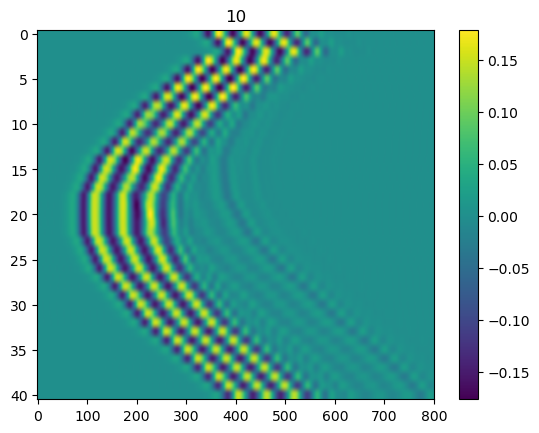

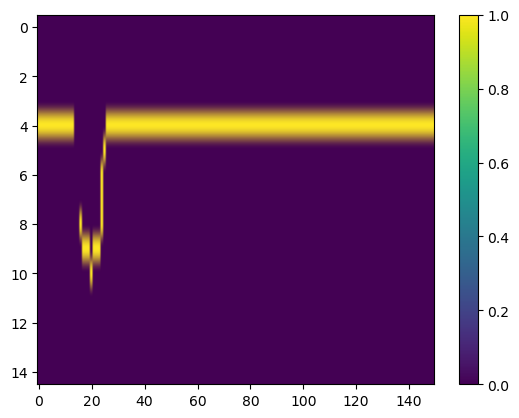

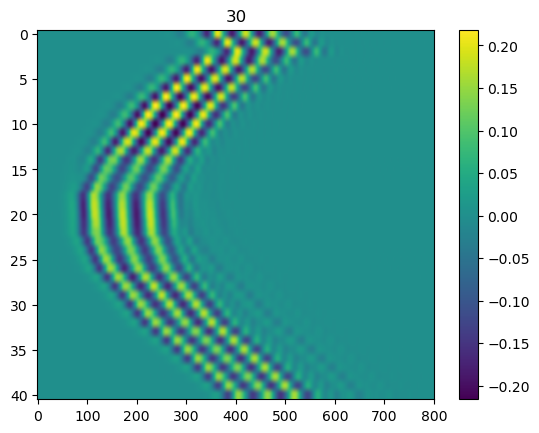

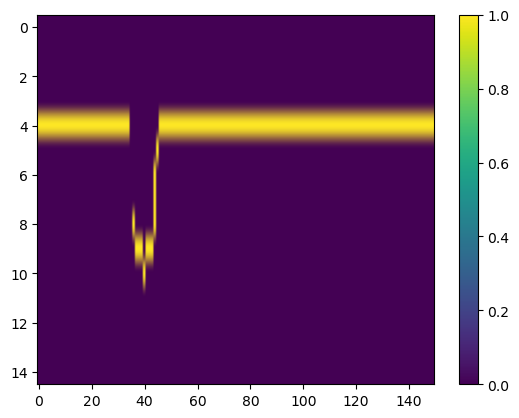

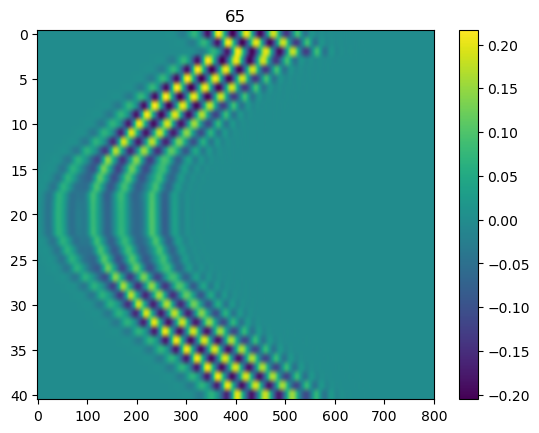

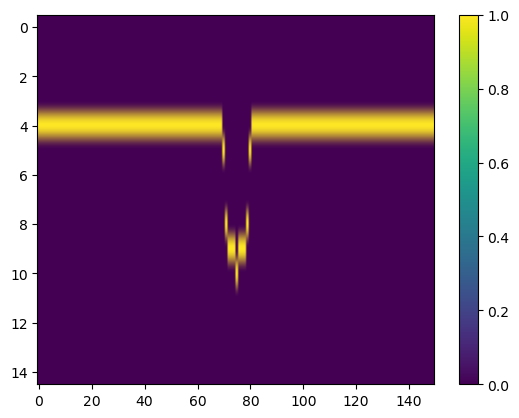

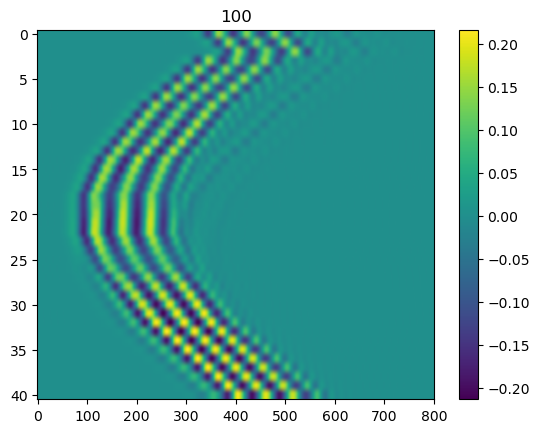

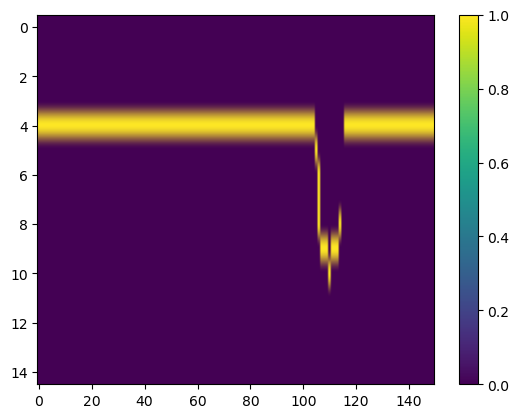

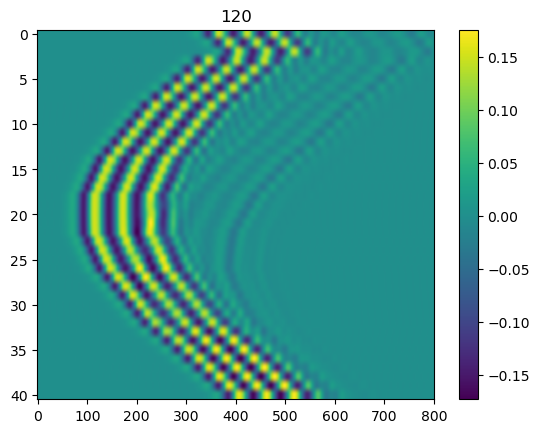

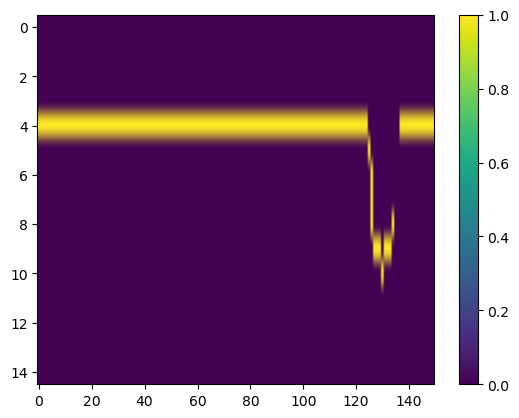

In [28]:
for example in [10,30,65,100,120]:
    plt.imshow(list_signals[example], aspect='auto')
    plt.colorbar()
    plt.title(str(example))
    plt.show()
    
    plt.imshow(list_outputs[example], aspect='auto')
    plt.colorbar()
    plt.show()

## (Optionnel) Associer les signaux pour pas qu'il y ai t de conflit avec le code de Maxime

In [29]:
X = X_normalized
y = list_outputs

# 6) Dataset personalisé

In [30]:
class SignalToImageDataset(Dataset):
    def __init__(self, X, y):
        # Conversion en tenseurs
        X = np.array(X, dtype=np.float32)  # (N, 41, 2001)
        y = np.array(y, dtype=np.float32)  # (N, 15, 150)
        
        self.X = torch.tensor(X).unsqueeze(1)  # (N, 1, 41, 2001)
        self.y = torch.tensor(y).unsqueeze(1) 
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 7) Modèle CNN

In [31]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)   # ↓
        )
        
        # Taille après encodeur (calcul dynamique)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 41, 2001)
            out = self.encoder(dummy)
            enc_h, enc_w = out.shape[2], out.shape[3]

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 8, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

        # On ajuste la dernière couche pour donner exactement (15,150)
        self.output_crop = (15, 150)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # Recadrer au cas où la taille n'est pas exacte
        h, w = self.output_crop
        x = x[:, :, :h, :w]
        return x
    
def pixel_accuracy(outputs, targets, threshold=0.5):
    """
    Calcule l'accuracy pixel par pixel.
    outputs : (N, 2250) -> probabilités
    targets : (N, 2250) -> 0 ou 1
    """
    preds = (outputs >= threshold).float()
    correct = (preds == targets).float().sum()
    total = targets.numel()
    return (correct / total).item()

def show_test_predictions(model, test_loader, device, num_samples=3, threshold=0.5):
    """
    Affiche num_samples prédictions du test set, reshaped en (15,150).
    """
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # Binarisation selon le seuil
            preds = (outputs >= threshold).float()
            preds=outputs

            for i in range(inputs.size(0)):
                pred_img = preds[i].view(15, 150).cpu().numpy()
                target_img = targets[i].view(15, 150).cpu().numpy()

                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(target_img, cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(pred_img, cmap="gray")
                axes[1].set_title("Prédiction")
                axes[1].axis("off")

                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

# 7b) Fonction de perte : BCE + Dice Loss

La **Dice Loss** mesure le chevauchement entre la prédiction et la vérité terrain.
Elle est particulièrement adaptée aux données déséquilibrées et force le modèle à bien reconstruire la **forme** complète de l'objet, pas seulement sa position.

`Loss = BCE + Dice`

# 7c) Architecture U-Net avec skip connections

Le U-Net relie chaque niveau de l'encodeur directement au décodeur correspondant via des **skip connections**.
Cela permet de préserver les détails spatiaux fins (forme, contours) qui sont perdus dans le goulot d'étranglement du CNN simple.

Chaque bloc inclut aussi une **BatchNorm** pour stabiliser l'entraînement.

In [32]:
class DoubleConv(nn.Module):
    """Deux convolutions consécutives avec BatchNorm et ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encodeur
        self.enc1 = DoubleConv(1, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Goulot d'étranglement
        self.bottleneck = DoubleConv(128, 256)

        # Décodeur
        self.up3  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)   # 128 (up) + 128 (skip)

        self.up2  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)    # 64  (up) + 64  (skip)

        self.up1  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)     # 32  (up) + 32  (skip)

        self.final   = nn.Conv2d(32, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

        self.output_size = (15, 150)

    def _crop(self, skip, target):
        """Recadre le skip pour correspondre à la taille de target."""
        _, _, h, w = target.shape
        return skip[:, :, :h, :w]

    def forward(self, x):
        # Encodeur + skip connections
        s1 = self.enc1(x)                    # (32, 41, 801)
        s2 = self.enc2(self.pool(s1))        # (64, 20, 400)
        s3 = self.enc3(self.pool(s2))        # (128, 10, 200)

        # Goulot
        b = self.bottleneck(self.pool(s3))   # (256, 5, 100)

        # Décodeur avec skip connections
        d3 = self.up3(b)                                      # (128, 10, 200)
        d3 = self.dec3(torch.cat([d3, self._crop(s3, d3)], dim=1))

        d2 = self.up2(d3)                                     # (64, 20, 400)
        d2 = self.dec2(torch.cat([d2, self._crop(s2, d2)], dim=1))

        d1 = self.up1(d2)                                     # (32, ~40, ~800)
        d1 = self.dec1(torch.cat([d1, self._crop(s1, d1)], dim=1))

        out = self.sigmoid(self.final(d1))

        # Recadrer à la taille de sortie cible
        h, w = self.output_size
        return out[:, :, :h, :w]

In [33]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCELoss()

    def forward(self, outputs, targets):
        bce_loss = self.bce(outputs, targets)

        # Dice Loss
        smooth = 1e-6
        outputs_flat = outputs.reshape(outputs.size(0), -1)
        targets_flat = targets.reshape(targets.size(0), -1)
        intersection = (outputs_flat * targets_flat).sum(dim=1)
        dice = 1 - (2 * intersection + smooth) / (outputs_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)
        dice_loss = dice.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

# 8) Fonction d'entrainement avec découpage

In [34]:
def train_and_validate(X, y, model_class, epochs=200, batch_size=8, lr=1e-3, patience=20):
    dataset = SignalToImageDataset(X, y)

    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)

    lengths = [80, 25, 26]
    train_set, val_set, test_set = random_split(dataset, lengths)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    
    model = model_class()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = BCEDiceLoss(bce_weight=0.5)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Early stopping vars
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    # Pour suivi des métriques
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        train_loss_sum = 0.0
        train_acc_sum = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item()
            train_acc_sum += pixel_accuracy(outputs, targets)

        # ---- Validation ----
        model.eval()
        val_loss_sum = 0.0
        val_acc_sum = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss_sum += loss.item()
                val_acc_sum += pixel_accuracy(outputs, targets)

        train_loss = train_loss_sum / len(train_loader)
        train_acc = train_acc_sum / len(train_loader)
        val_loss = val_loss_sum / len(val_loader)
        val_acc = val_acc_sum / len(val_loader)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} "
              f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # ---- Early stopping check ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # ---- Restore best model ----
    model.load_state_dict(best_model_wts)

    # ---- Test set evaluation ----
    model.eval()
    test_loss_sum = 0.0
    test_acc_sum = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss_sum += loss.item()
            test_acc_sum += pixel_accuracy(outputs, targets)

    test_loss = test_loss_sum / len(test_loader)
    test_acc = test_acc_sum / len(test_loader)

    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    
    # ---- Courbes ----
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f"Test Loss ({test_loss:.4f})")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss vs Epochs")

    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f"Test Acc ({test_acc:.4f})")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy vs Epochs")

    plt.show()

    # ---- Sauvegarde du modèle ----
    torch.save(model.state_dict(), "model_unet.pth")
    print("Modèle sauvegardé dans model_unet.pth")

    return model, train_loader, val_loader, test_loader

# 9) Lancement de l'entrainement

In [35]:
model, train_loader, val_loader, test_loader = train_and_validate(X, y, UNet)

RuntimeError: GET was unable to find an engine to execute this computation

# 9b) Recharger le modèle sans réentraîner

Exécuter cette cellule si le modèle a déjà été entraîné et sauvegardé (`model_cnn.pth` existe).

In [36]:
if os.path.exists("model_unet.pth"):
    device = torch.device("cpu")

    model = UNet().to(device)
    model.load_state_dict(torch.load("model_unet.pth", map_location=device))
    model.eval()

    # Recréer les dataloaders pour la visualisation
    dataset = SignalToImageDataset(X, y)
    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)
    train_set, val_set, test_set = random_split(dataset, [80, 25, 26])
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)
    test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False)

    print("Modèle chargé depuis model_cnn.pth")
else:
    print("⚠️ Aucun fichier model_cnn.pth trouvé. Lance d'abord la cellule d'entraînement (section 9).")

Modèle chargé depuis model_cnn.pth


# 10) Présentation des résultats

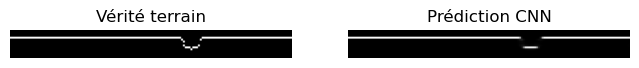

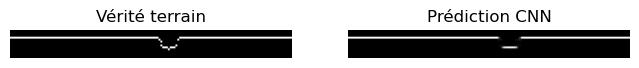

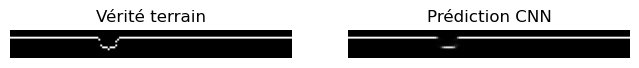

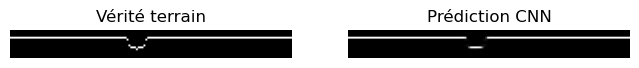

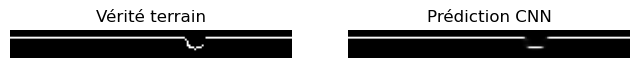

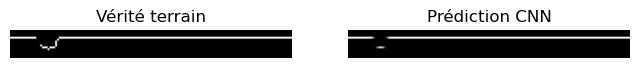

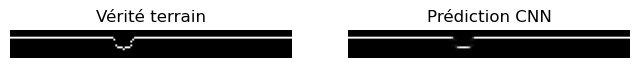

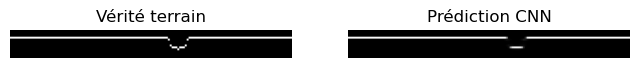

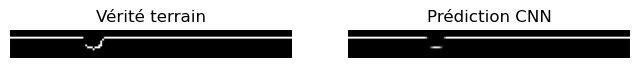

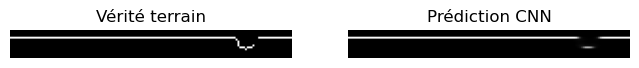

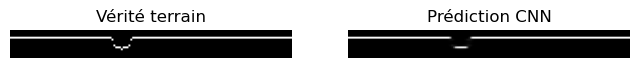

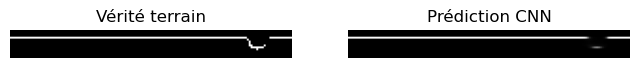

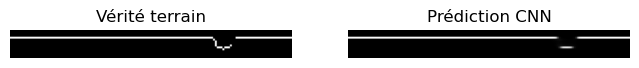

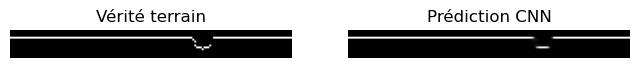

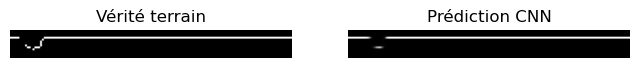

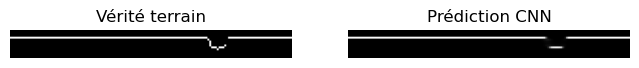

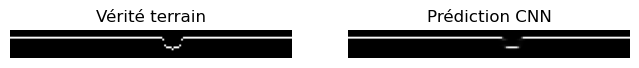

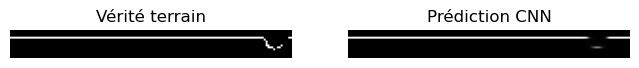

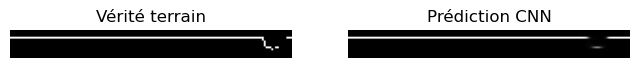

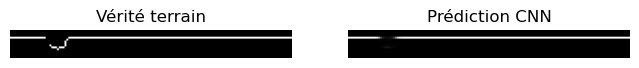

In [37]:
def show_predictions(model, loader, device, num_samples=3):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = outputs.cpu().numpy()

            for i in range(inputs.size(0)):
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(targets[i].cpu().squeeze(), cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(preds[i].squeeze(), cmap="gray")
                axes[1].set_title("Prédiction CNN")
                axes[1].axis("off")
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return
                
device = torch.device("cpu")
show_predictions(model, test_loader, device, num_samples=20)

# 11) Diagnostic des prédictions

## 11a) Distribution des valeurs prédites

Vérifie si le modèle prédit des valeurs variées ou s'effondre vers 0 ou 1.

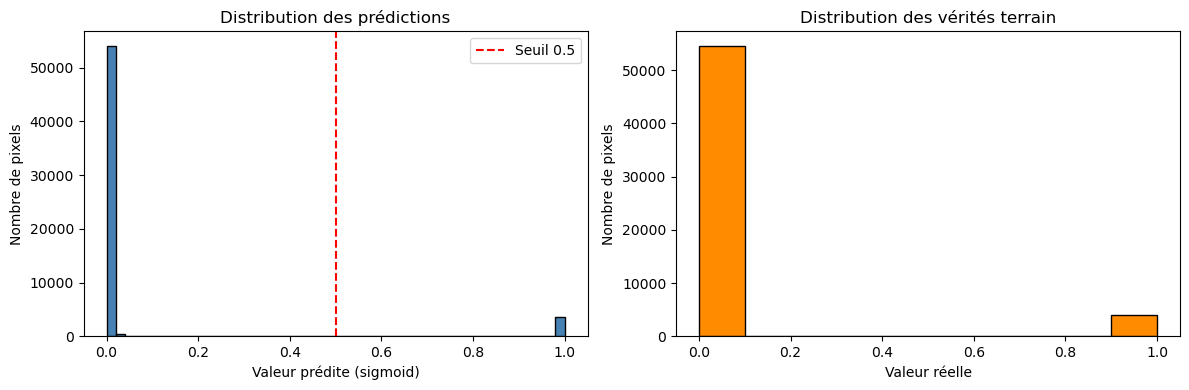

Ratio de pixels positifs (=1) dans la vérité terrain : 0.0668 (6.68%)
Moyenne des prédictions : 0.0649
Std des prédictions     : 0.2435


In [40]:
device = torch.device("cpu")

all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu().numpy().flatten())
        all_targets.append(targets.cpu().numpy().flatten())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Histogramme des valeurs prédites
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(all_preds, bins=50, color='steelblue', edgecolor='black')
plt.xlabel("Valeur prédite (sigmoid)")
plt.ylabel("Nombre de pixels")
plt.title("Distribution des prédictions")
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil 0.5")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(all_targets, bins=10, color='darkorange', edgecolor='black')
plt.xlabel("Valeur réelle")
plt.ylabel("Nombre de pixels")
plt.title("Distribution des vérités terrain")

plt.tight_layout()
plt.show()

# Ratio de pixels positifs dans la vérité terrain
ratio_positifs = all_targets.mean()
print(f"Ratio de pixels positifs (=1) dans la vérité terrain : {ratio_positifs:.4f} ({ratio_positifs*100:.2f}%)")
print(f"Moyenne des prédictions : {all_preds.mean():.4f}")
print(f"Std des prédictions     : {all_preds.std():.4f}")

## 11b) Métriques de segmentation : Précision, Rappel, F1, IoU

La **pixel accuracy** seule est trompeuse quand les classes sont déséquilibrées.
- **Précision** : parmi les pixels prédits à 1, combien sont vrais ?
- **Rappel** : parmi les pixels réels à 1, combien sont détectés ?
- **F1** : moyenne harmonique précision/rappel
- **IoU** (Intersection over Union) : métrique standard en segmentation

=== Métriques sur le test set ===
  Accuracy    : 0.9939
  Précision   : 0.9706
  Rappel      : 0.9365
  F1          : 0.9532
  IoU         : 0.9107

Meilleur seuil (F1 max) : 0.59  →  F1 = 0.9540


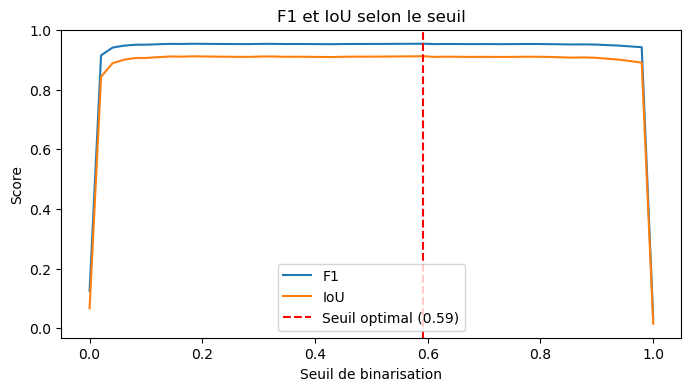

In [41]:
def compute_metrics(preds_prob, targets, threshold=0.5):
    preds = (preds_prob >= threshold).astype(float)
    
    TP = ((preds == 1) & (targets == 1)).sum()
    FP = ((preds == 1) & (targets == 0)).sum()
    FN = ((preds == 0) & (targets == 1)).sum()
    TN = ((preds == 0) & (targets == 0)).sum()
    
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    iou       = TP / (TP + FP + FN + 1e-8)
    accuracy  = (TP + TN) / (TP + FP + FN + TN + 1e-8)
    
    return {"Accuracy": accuracy, "Précision": precision, "Rappel": recall, "F1": f1, "IoU": iou}

metrics = compute_metrics(all_preds, all_targets)
print("=== Métriques sur le test set ===")
for name, val in metrics.items():
    print(f"  {name:<12}: {val:.4f}")

# Courbe F1 selon le seuil
thresholds = np.linspace(0, 1, 50)
f1_scores  = [compute_metrics(all_preds, all_targets, t)["F1"] for t in thresholds]
iou_scores = [compute_metrics(all_preds, all_targets, t)["IoU"] for t in thresholds]

best_t = thresholds[np.argmax(f1_scores)]
print(f"\nMeilleur seuil (F1 max) : {best_t:.2f}  →  F1 = {max(f1_scores):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores,  label="F1")
plt.plot(thresholds, iou_scores, label="IoU")
plt.axvline(x=best_t, color='red', linestyle='--', label=f"Seuil optimal ({best_t:.2f})")
plt.xlabel("Seuil de binarisation")
plt.ylabel("Score")
plt.title("F1 et IoU selon le seuil")
plt.legend()
plt.show()

## 11c) Visualisation côte à côte avec superposition des erreurs

Rouge = faux positifs (prédit 1, réel 0) | Bleu = faux négatifs (prédit 0, réel 1)

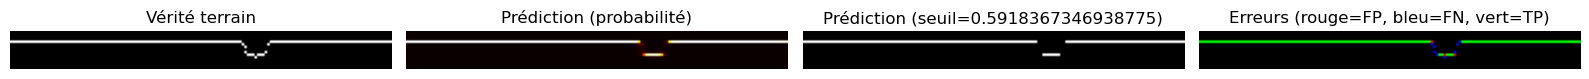

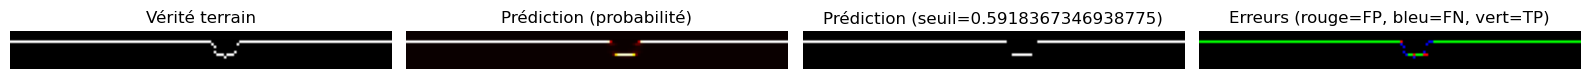

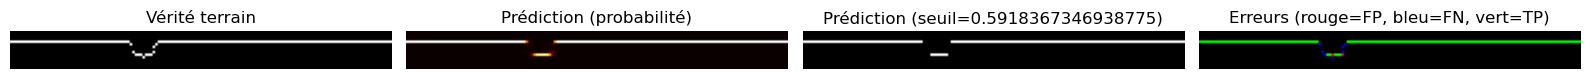

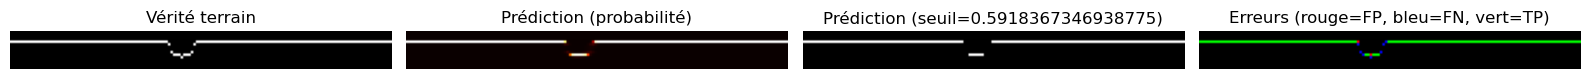

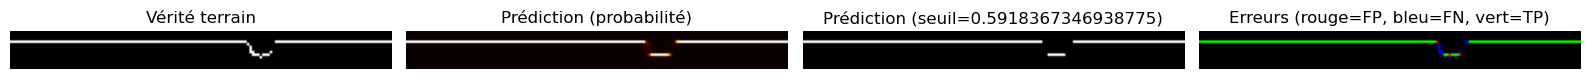

In [42]:
def show_diagnostic(model, loader, device, num_samples=5, threshold=0.5):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            for i in range(inputs.size(0)):
                pred_prob = outputs[i].squeeze().cpu().numpy()
                pred_bin  = (pred_prob >= threshold).astype(float)
                target    = targets[i].squeeze().cpu().numpy()

                # Carte d'erreurs RGB
                error_map = np.zeros((*target.shape, 3))
                error_map[(pred_bin == 1) & (target == 1)] = [0, 1, 0]   # Vert  : vrai positif
                error_map[(pred_bin == 1) & (target == 0)] = [1, 0, 0]   # Rouge : faux positif
                error_map[(pred_bin == 0) & (target == 1)] = [0, 0, 1]   # Bleu  : faux négatif

                fig, axes = plt.subplots(1, 4, figsize=(16, 3))

                axes[0].imshow(target, cmap="gray", vmin=0, vmax=1)
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(pred_prob, cmap="hot", vmin=0, vmax=1)
                axes[1].set_title("Prédiction (probabilité)")
                axes[1].axis("off")

                axes[2].imshow(pred_bin, cmap="gray", vmin=0, vmax=1)
                axes[2].set_title(f"Prédiction (seuil={threshold})")
                axes[2].axis("off")

                axes[3].imshow(error_map)
                axes[3].set_title("Erreurs (rouge=FP, bleu=FN, vert=TP)")
                axes[3].axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

show_diagnostic(model, test_loader, device, num_samples=5, threshold=best_t)

In [45]:
# ════════════════════════════════════════════════════════════════════
# EXPLICABILITÉ : Saliency Maps + Grad-CAM 1D sur UNet2Ch
# ════════════════════════════════════════════════════════════════════

def compute_saliency(model, x, device):
    """
    Calcule la saliency map par rapport à l'entrée.
    x : (B, 9, 801) tensor
    Retourne : (B, 9, 801) importance absolue par position temporelle
    """
    model.eval()
    x_in = x.clone().to(device).requires_grad_(True)
    output = model(x_in)                     # (B, 1, 150, 150)
    # Score = somme des probabilités sur les pixels positifs prédits
    score = torch.sigmoid(output).sum()
    model.zero_grad()
    score.backward()
    saliency = x_in.grad.abs().cpu()         # (B, 9, 801)
    return saliency

def plot_importance_temporal(importance_mean, importance_std, method='Saliency',
                              signal_start=1200, fs=33333):
    """
    Affiche l'importance temporelle moyennée sur tous les échantillons.
    importance_mean : (9, 801)
    importance_std  : (9, 801)
    fs : fréquence d'échantillonnage en Hz (pour l'axe temporel)
    """
    n_cap = importance_mean.shape[0]
    L     = importance_mean.shape[1]
    t_ms  = (np.arange(L) + signal_start) / fs * 1000  # temps en ms

    fig, axes = plt.subplots(n_cap, 1, figsize=(14, n_cap * 1.4), sharex=True)
    if n_cap == 1:
        axes = [axes]

    # Importance globale (moyenne capteurs) pour détecter la fenêtre clé
    global_imp = importance_mean.mean(axis=0)  # (801,)

    # Fenêtre de pic (top 10% des valeurs)
    threshold_peak = np.percentile(global_imp, 90)
    peak_mask = global_imp >= threshold_peak
    if peak_mask.any():
        peak_start_ms = t_ms[np.where(peak_mask)[0].min()]
        peak_end_ms   = t_ms[np.where(peak_mask)[0].max()]

    for c in range(n_cap):
        mu  = importance_mean[c]
        std = importance_std[c]
        axes[c].fill_between(t_ms, mu - std, mu + std, alpha=0.25, color='steelblue')
        axes[c].plot(t_ms, mu, color='steelblue', linewidth=1.2)
        if peak_mask.any():
            axes[c].axvspan(peak_start_ms, peak_end_ms, alpha=0.15,
                            color='red', label='Zone clé (top 10%)')
        axes[c].set_ylabel(f'Cap. {c+1}', fontsize=8)
        axes[c].set_yticks([])

    axes[-1].set_xlabel('Temps (ms)', fontsize=9)
    if peak_mask.any():
        axes[0].legend(fontsize=8)
    fig.suptitle(
        f'{method} — Importance temporelle moyenne\n'
        f'(zone rouge = fenêtre la plus utilisée par le réseau)',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    if peak_mask.any():
        print(f'Fenêtre clé détectée : {peak_start_ms:.2f} ms → {peak_end_ms:.2f} ms')
        print(f'  Indices signal     : {np.where(peak_mask)[0].min()} → {np.where(peak_mask)[0].max()}')


def plot_importance_heatmap(importance_mean, method='Saliency', signal_start=1200, fs=33333):
    """
    Affiche une heatmap (capteurs x temps) de l'importance.
    Permet de voir si les zones importantes sont décalées entre capteurs
    (ce qui indiquerait que le réseau utilise bien les délais inter-capteurs).
    """
    L    = importance_mean.shape[1]
    t_ms = (np.arange(L) + signal_start) / fs * 1000

    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(
        importance_mean, aspect='auto', cmap='hot',
        extent=[t_ms[0], t_ms[-1], importance_mean.shape[0]+0.5, 0.5]
    )
    plt.colorbar(im, ax=ax, label='Importance')
    ax.set_xlabel('Temps (ms)')
    ax.set_ylabel('Capteur')
    ax.set_yticks(range(1, importance_mean.shape[0]+1))
    ax.set_title(
        f'{method} — Heatmap importance (capteurs x temps)\n'
        f'Des décalages horizontaux entre capteurs indiquent que le réseau\n'
        f'exploite les délais inter-capteurs pour estimer l\'angle.',
        fontsize=9
    )
    plt.tight_layout()
    plt.show()


print('Fonctions XAI definies.')


Fonctions XAI definies.


Calcul des Saliency Maps...
Saliency calculee sur 50 echantillons.


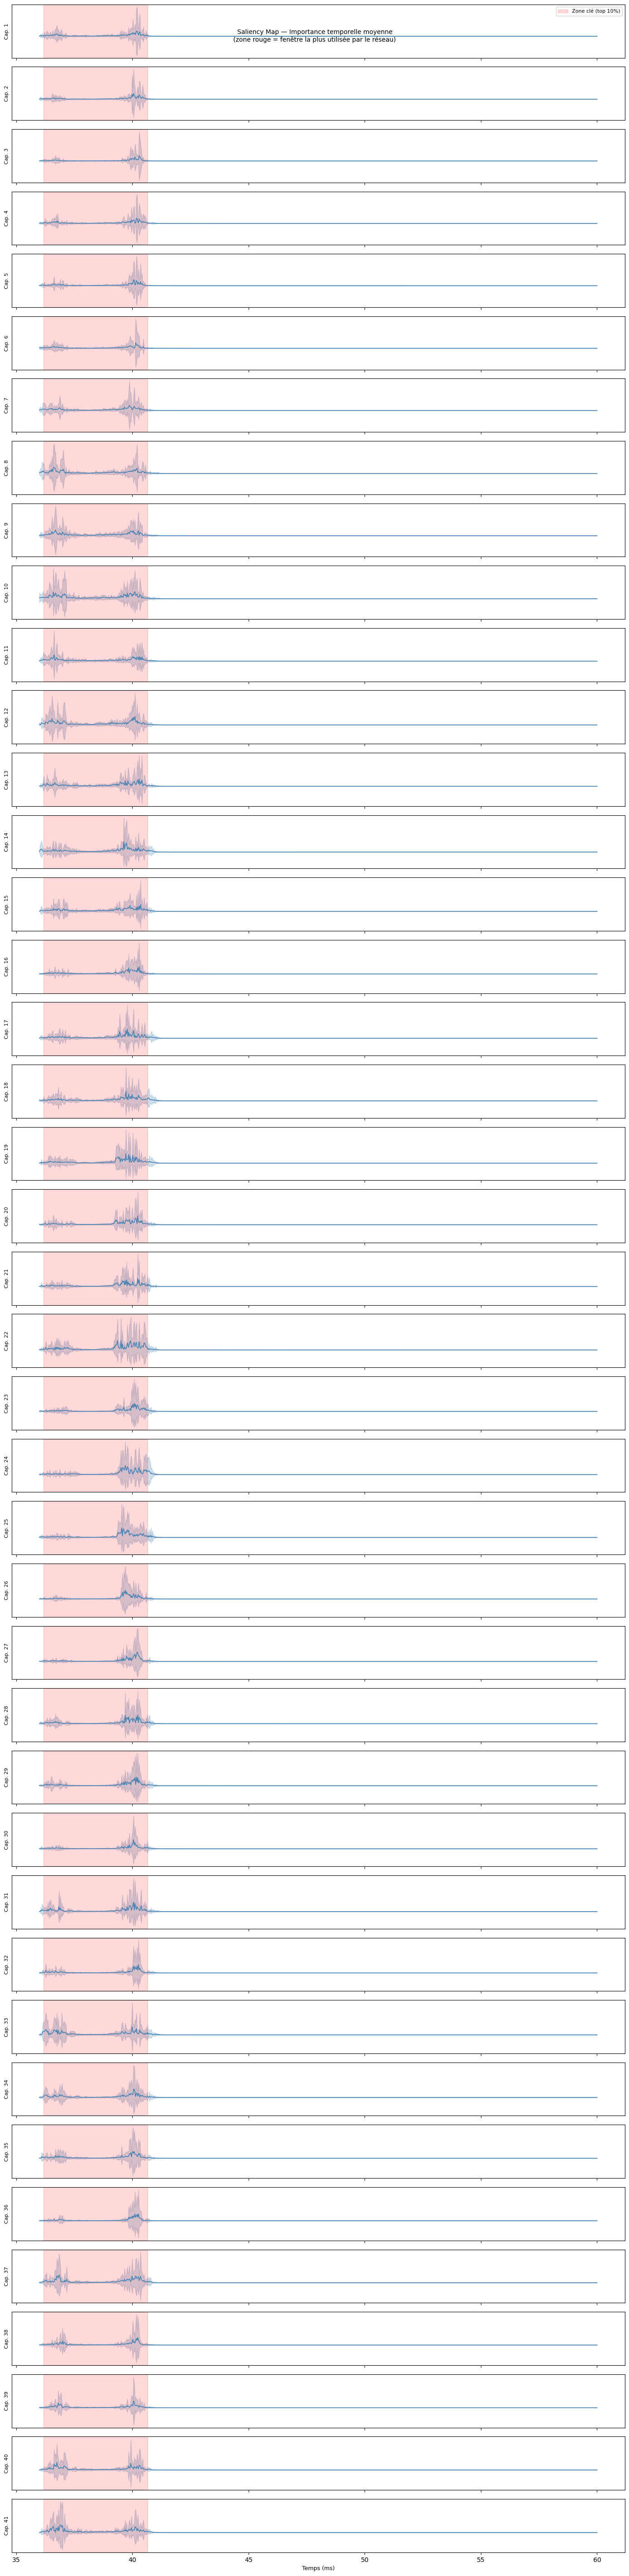

Fenêtre clé détectée : 36.18 ms → 40.65 ms
  Indices signal     : 6 → 155


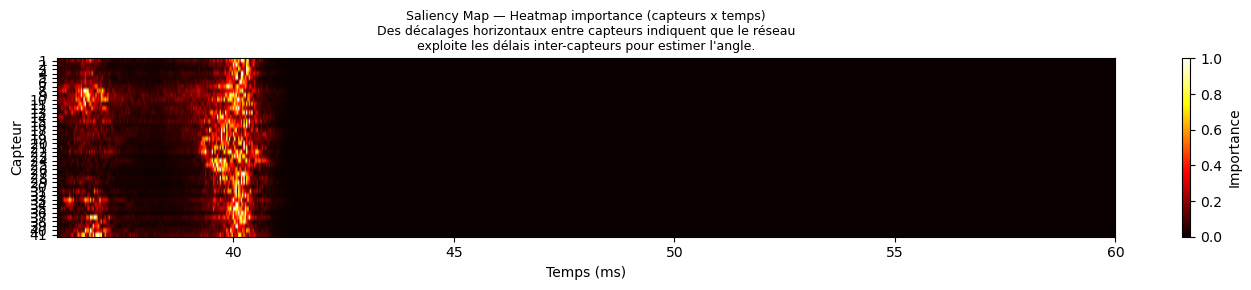

In [47]:
# ── Calcul des saliency maps et Grad-CAM sur le dataset de test ──────────────
# Pour une analyse par classe, remplacer test_loader par
# test_loaders_by_class['Rond'] etc.

N_SAMPLES_XAI = 50   # nombre d'échantillons à analyser (augmenter pour plus de robustesse)

# ── 1) Saliency Maps ─────────────────────────────────────────────────────────
print('Calcul des Saliency Maps...')
sal_all = []
model.eval()

for x, y in test_loader:
    sal = compute_saliency(model, x, device)  # (B, 9, 801)
    sal_all.append(sal.numpy())
    if sum(s.shape[0] for s in sal_all) >= N_SAMPLES_XAI:
        break

sal_all   = np.concatenate(sal_all, axis=0)[:N_SAMPLES_XAI]  # (N, 9, 801)
sal_mean  = sal_all.squeeze(1).mean(axis=0)   # (9, 801)
sal_std   = sal_all.squeeze(1).std(axis=0)    # (9, 801)

# Normaliser par capteur pour faciliter la comparaison
for c in range(sal_mean.shape[0]):
    vmax = sal_mean[c].max()
    if vmax > 0:
        sal_mean[c] /= vmax
        sal_std[c]  /= vmax

print(f'Saliency calculee sur {N_SAMPLES_XAI} echantillons.')
plot_importance_temporal(sal_mean, sal_std, method='Saliency Map')
plot_importance_heatmap(sal_mean, method='Saliency Map')

(41, 801)


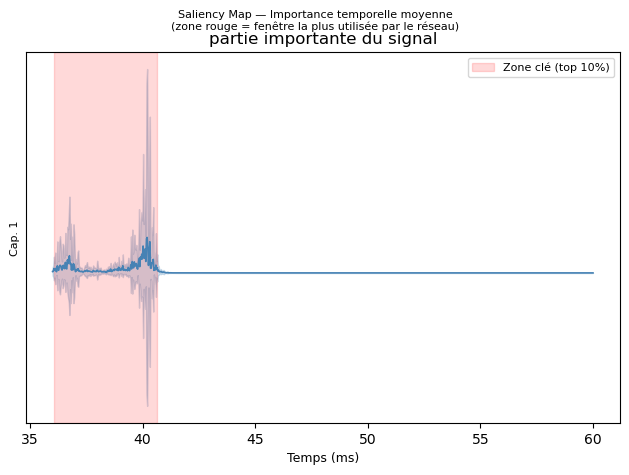

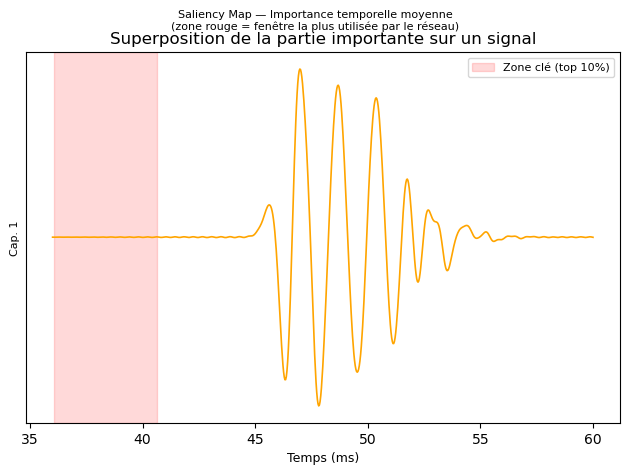

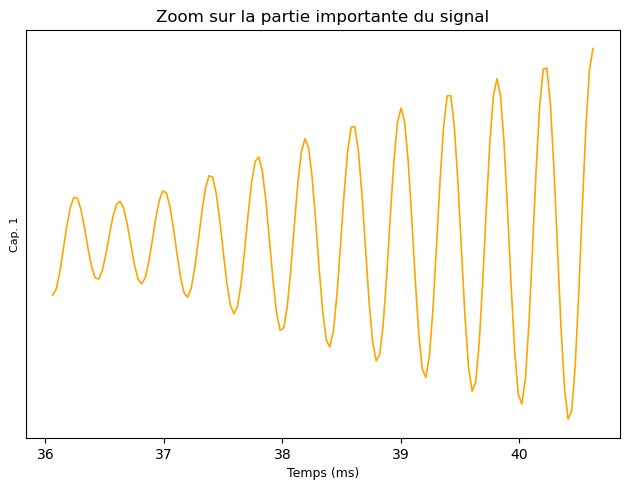

Fenêtre clé détectée : 36.06 ms → 40.65 ms
  Indices signal     : 2 → 155


In [61]:
def plot_importance_temporal_for_a_capteur(importance_mean, importance_std, method='Saliency',
                              signal_start=1200, fs=33333):
    """
    Affiche l'importance temporelle moyennée sur tous les échantillons.
    importance_mean : (801,)
    importance_std  : (801,)
    fs : fréquence d'échantillonnage en Hz (pour l'axe temporel)
    """
    n_cap = 1
    L     = importance_mean.shape[0]
    t_ms  = (np.arange(L) + signal_start) / fs * 1000  # temps en ms

    # Fenêtre de pic (top 10% des valeurs)
    threshold_peak = np.percentile(importance_mean, 90)
    peak_mask = importance_mean >= threshold_peak
    if peak_mask.any():
        peak_start_idx = np.where(peak_mask)[0].min()
        peak_start_ms = t_ms[peak_start_idx]
        peak_end_idx = np.where(peak_mask)[0].max()
        peak_end_ms   = t_ms[peak_end_idx]
    plt.fill_between(t_ms, importance_mean - importance_std, importance_mean + importance_std, alpha=0.25, color='steelblue')
    plt.plot(t_ms, importance_mean, color='steelblue', linewidth=1.2)
    if peak_mask.any():
        plt.axvspan(peak_start_ms, peak_end_ms, alpha=0.15,
                            color='red', label='Zone clé (top 10%)')
    plt.ylabel(f'Cap. {1}', fontsize=8)
    plt.yticks([])

    plt.xlabel('Temps (ms)', fontsize=9)
    if peak_mask.any():
        plt.legend(fontsize=8)
    plt.suptitle(
        f'{method} — Importance temporelle moyenne\n'
        f'(zone rouge = fenêtre la plus utilisée par le réseau)',
        fontsize=8
    )
    plt.tight_layout()
    plt.title('partie importante du signal')
    plt.show()
    
    # Graphique partie importante du signal
    plt.plot(t_ms, X[0][0], color='orange', linewidth=1.2)
    if peak_mask.any():
        plt.axvspan(peak_start_ms, peak_end_ms, alpha=0.15,
                            color='red', label='Zone clé (top 10%)')
    plt.ylabel(f'Cap. {1}', fontsize=8)
    plt.yticks([])

    plt.xlabel('Temps (ms)', fontsize=9)
    if peak_mask.any():
        plt.legend(fontsize=8)
    plt.suptitle(
        f'{method} — Importance temporelle moyenne\n'
        f'(zone rouge = fenêtre la plus utilisée par le réseau)',
        fontsize=8
    )
    plt.tight_layout()
    plt.title('Superposition de la partie importante sur un signal')
    plt.show()
    
    # Zoom sur la partie importante 
    plt.plot(t_ms[peak_start_idx:peak_end_idx], X[0][0][peak_start_idx:peak_end_idx], color='orange', linewidth=1.2)
    plt.ylabel(f'Cap. {1}', fontsize=8)
    plt.yticks([])

    plt.xlabel('Temps (ms)', fontsize=9)
    plt.tight_layout()
    plt.title('Zoom sur la partie importante du signal')
    plt.show()

    if peak_mask.any():
        print(f'Fenêtre clé détectée : {peak_start_ms:.2f} ms → {peak_end_ms:.2f} ms')
        print(f'  Indices signal     : {np.where(peak_mask)[0].min()} → {np.where(peak_mask)[0].max()}')
print(sal_mean.shape)
plot_importance_temporal_for_a_capteur(sal_mean[0], sal_std[0], method='Saliency Map')

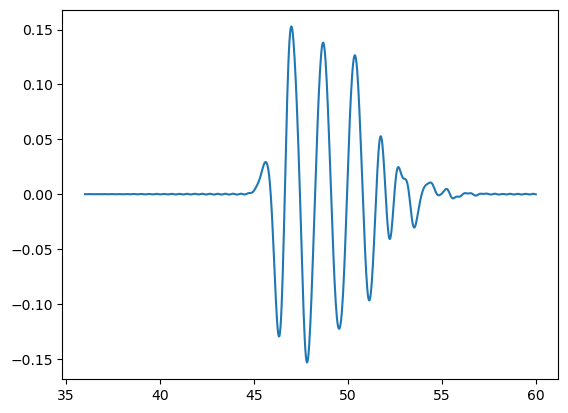

In [60]:
L     = sal_mean[0].shape[0]
t_ms  = (np.arange(L) + 1200) / 33333 * 1000  # temps en ms
plt.plot(t_ms, X[0][0])

(131, 41, 801)
(131, 41)
(131, 41)
(41,)


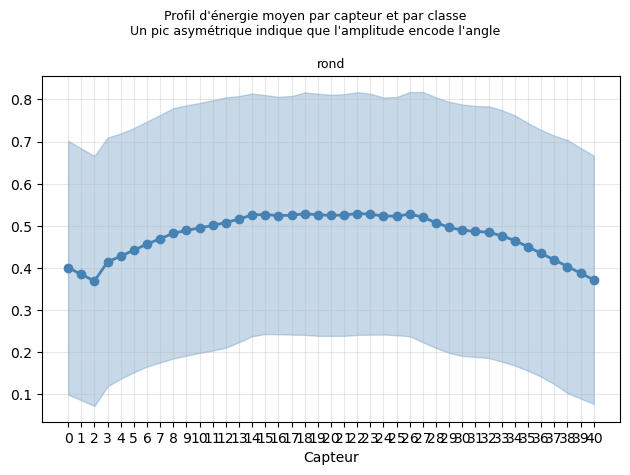

Variance inter-capteurs par classe (plus c'est élevé, plus le profil est asymétrique) :


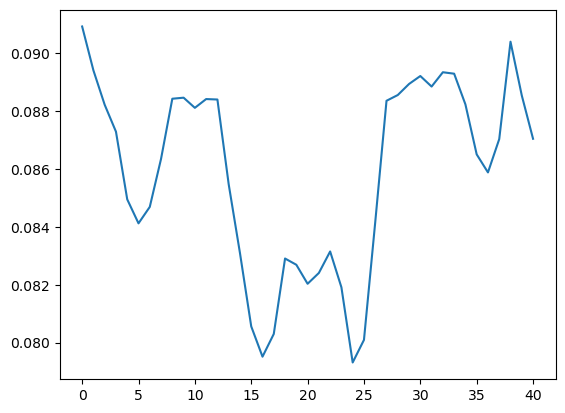

In [64]:
# ════════════════════════════════════════════════════════════════════
# ANALYSE 1 : Profil d'amplitude inter-capteurs
# Est-ce que le réseau utilise l'énergie par capteur pour estimer l'angle ?
# ════════════════════════════════════════════════════════════════════

def compute_energy_profile(X,signal_start=0):
    """
    Calcule l'énergie RMS de chaque capteur pour chaque échantillon.
    X : (N, 9, 801)
    Retourne : (N, 9) — énergie par capteur
    """
    return np.sqrt((X ** 2).mean(axis=2))   # (N, 8)
# Calculer le profil d'énergie sur le test set
X_test = X   # (N_test, 9, 801)
print(X_test.shape)
energy = compute_energy_profile(X_test)   # (N_test, 8)
# Normaliser chaque profil entre 0 et 1 pour comparer les formes
energy_norm = energy - energy.min(axis=1, keepdims=True)
denom = energy_norm.max(axis=1, keepdims=True)
denom[denom == 0] = 1
energy_norm = energy_norm / denom   # (N_test, 8)
print(energy_norm.shape)

e_class = energy_norm       # (N_class, 9)

print(energy_norm.shape)
mu  = energy_norm.mean(axis=0)        # (9,)
std = energy_norm.std(axis=0)         # (9,)
print(mu.shape)

plt.fill_between(range(41), mu - std, mu + std, alpha=0.3, color='steelblue')
plt.plot(range(41), mu, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.title('rond', fontsize=9)
plt.xlabel('Capteur')
plt.xticks(range(41))
plt.grid(True, alpha=0.3)

plt.suptitle(
    'Profil d\'énergie moyen par capteur et par classe\n'
    'Un pic asymétrique indique que l\'amplitude encode l\'angle',
    fontsize=9
)
plt.tight_layout()
plt.show()

# Stats : variance inter-capteurs (mesure de l'asymétrie du profil)
print('Variance inter-capteurs par classe (plus c\'est élevé, plus le profil est asymétrique) :')
var  = energy_norm.var(axis=0)
plt.plot(range(41), var)

Calcul des corrélations croisées (peut prendre ~30s)...
Délais inter-capteurs calculés sur 50 échantillons.
Délai moyen relatif au capteur 1 (ms) :
  Capteur 2 : +0.3524 ms ± 0.0130
  Capteur 3 : +0.7099 ms ± 0.0142
  Capteur 4 : -0.4834 ms ± 0.0096
  Capteur 5 : -0.9573 ms ± 0.0087
  Capteur 6 : -1.3876 ms ± 0.0130
  Capteur 7 : -1.7970 ms ± 0.0090
  Capteur 8 : -2.3409 ms ± 0.0052


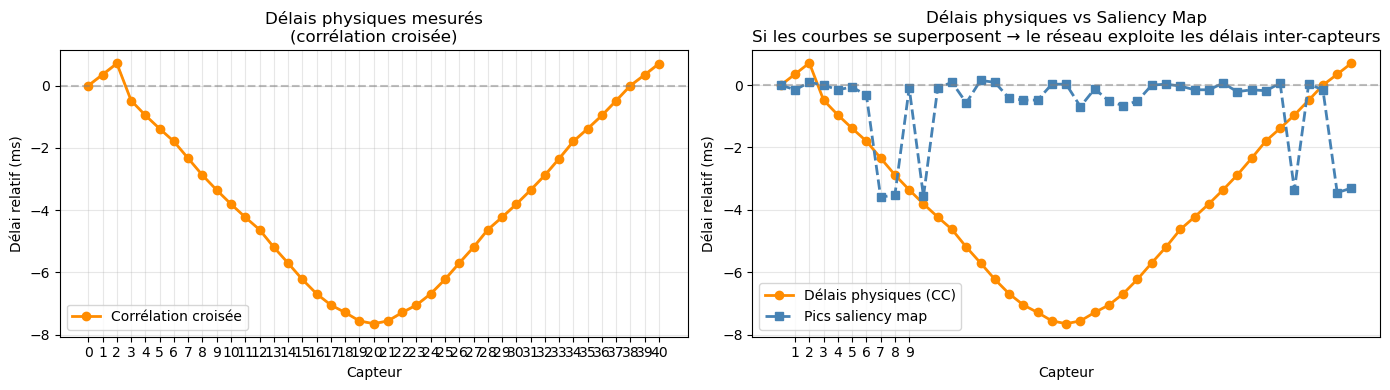

In [66]:
# ════════════════════════════════════════════════════════════════════
# ANALYSE 2 : Corrélation croisée inter-capteurs
# Mesure le délai physique réel entre capteurs
# et le compare à ce que la saliency map détecte
# ════════════════════════════════════════════════════════════════════

def compute_cross_correlation_delays(X, ref_capteur=0, fs=33333):
    """
    Calcule le délai entre le capteur de référence et chaque autre capteur
    via corrélation croisée.
    X  : (N, 9, 801)
    Retourne : (N, 8) délais en ms (capteurs 1-8 relatifs au capteur 0)
    """
    N, n_cap, L = X.shape
    delays = np.zeros((N, n_cap - 1))

    for i in range(N):
        ref = X[i, ref_capteur]       # signal de référence (801,)
        for j in range(1, n_cap):
            sig = X[i, j]
            # Corrélation croisée normalisée
            corr = np.correlate(sig, ref, mode='full')   # (1601,)
            lag  = np.argmax(np.abs(corr)) - (L - 1)    # décalage en samples
            delays[i, j-1] = lag / fs * 1000             # conversion en ms
    return delays

print('Calcul des corrélations croisées (peut prendre ~30s)...')
X_test_raw = X_raw   # signaux non normalisés pour la corrélation

# Calculer sur un sous-ensemble pour la rapidité
N_CC = 50
delays = compute_cross_correlation_delays(X_test_raw[:,:N_CC])  # (N_CC, 8)

delay_mean = delays.mean(axis=0)   # (8,) délai moyen par capteur
delay_std  = delays.std(axis=0)

print(f'Délais inter-capteurs calculés sur {N_CC} échantillons.')
print('Délai moyen relatif au capteur 1 (ms) :')
for j in range(7):
    print(f'  Capteur {j+2} : {delay_mean[j]:+.4f} ms ± {delay_std[j]:.4f}')

# ── Comparer délais physiques vs pics de saliency map ────────────────────────
# Récupérer les pics de la saliency map (calculée à la cellule précédente)
L    = sal_mean.shape[1]
t_ms = (np.arange(L) + 1200) / 33333 * 1000

sal_peak_times = []
for c in range(sal_mean.shape[0]):
    sal_peak_times.append(t_ms[sal_mean[c].argmax()])

# Délais saliency relatifs au capteur 1
sal_delays_rel = np.array(sal_peak_times) - sal_peak_times[0]   # (9,)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Gauche : délais physiques (corrélation croisée) ──────────────────────────
delay_all = np.concatenate([[0], delay_mean])   # ajouter capteur 1 = 0
axes[0].fill_between(
    range(41),
    delay_all - np.concatenate([[0], delay_std]),
    delay_all + np.concatenate([[0], delay_std]),
    alpha=0.3, color='darkorange'
)
axes[0].plot(range(41), delay_all, 'o-', color='darkorange',
             linewidth=2, markersize=6, label='Corrélation croisée')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Capteur')
axes[0].set_ylabel('Délai relatif (ms)')
axes[0].set_title('Délais physiques mesurés\n(corrélation croisée)')
axes[0].set_xticks(range(41))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ── Droite : comparaison délais physiques vs saliency map ────────────────────
axes[1].plot(range(41), delay_all, 'o-', color='darkorange',
             linewidth=2, markersize=6, label='Délais physiques (CC)')
axes[1].plot(range(41), sal_delays_rel, 's--', color='steelblue',
             linewidth=2, markersize=6, label='Pics saliency map')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Capteur')
axes[1].set_ylabel('Délai relatif (ms)')
axes[1].set_title(
    'Délais physiques vs Saliency Map\n'
    'Si les courbes se superposent → le réseau exploite les délais inter-capteurs'
)
axes[1].set_xticks(range(1, 10))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
# ════════════════════════════════════════════════════════════════════
# INTERPRÉTATION : le réseau utilise-t-il les délais ou l'amplitude ?
# ════════════════════════════════════════════════════════════════════

from scipy.stats import pearsonr

# Corrélation entre délais physiques et pics saliency
corr_delays, p_delays = pearsonr(delay_all[1:], sal_delays_rel[1:])

# Variance du profil d'énergie (mesure de l'asymétrie)
var_energie = energy_norm.var(axis=1).mean()

print('=' * 55)
print('  DIAGNOSTIC : source d\'information angulaire')
print('=' * 55)
print(f'\n  Corrélation délais physiques / saliency map :')
print(f'    r = {corr_delays:.3f}  (p = {p_delays:.4f})')
if abs(corr_delays) > 0.7 and p_delays < 0.05:
    print('    → ✅ Le réseau exploite les délais inter-capteurs')
else:
    print('    → ❌ Le réseau n\'exploite PAS les délais inter-capteurs')

print(f'\n  Variance inter-capteurs du profil d\'énergie :')
print(f'    var = {var_energie:.4f}')
if var_energie > 0.05:
    print('    → ✅ Le profil d\'amplitude est asymétrique (info angulaire présente)')
else:
    print('    → ❌ Le profil d\'amplitude est plat (peu d\'info angulaire)')

print('\n  Conclusion :')
if abs(corr_delays) > 0.7:
    print('    Le réseau utilise principalement les DÉLAIS inter-capteurs.')
    print('    → Équivalent au beamforming classique.')
    print('    → Cohérent avec la biologie du dauphin (stéréophonie).')
elif var_energie > 0.05:
    print('    Le réseau utilise principalement l\'AMPLITUDE par capteur.')
    print('    → Plus robuste au bruit mais moins précis en angle.')
else:
    print('    Source d\'information angulaire non identifiée clairement.')
    print('    → Essayer avec un dataset mono-classe à angles variés.')
print('=' * 55)

  DIAGNOSTIC : source d'information angulaire

  Corrélation délais physiques / saliency map :
    r = -0.276  (p = 0.0846)
    → ❌ Le réseau n'exploite PAS les délais inter-capteurs

  Variance inter-capteurs du profil d'énergie :
    var = 0.0801
    → ✅ Le profil d'amplitude est asymétrique (info angulaire présente)

  Conclusion :
    Le réseau utilise principalement l'AMPLITUDE par capteur.
    → Plus robuste au bruit mais moins précis en angle.
